<a href="https://colab.research.google.com/github/jrmccluskey/beam/blob/geminiNotebook/examples/notebooks/beam-ml/run_inference_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title ###### Licensed to the Apache Software Foundation (ASF), Version 2.0 (the "License")

# Licensed to the Apache Software Foundation (ASF) under one
# or more contributor license agreements. See the NOTICE file
# distributed with this work for additional information
# regarding copyright ownership. The ASF licenses this file
# to you under the Apache License, Version 2.0 (the
# "License"); you may not use this file except in compliance
# with the License. You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing,
# software distributed under the License is distributed on an
# "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY
# KIND, either express or implied. See the License for the
# specific language governing permissions and limitations
# under the License

# Apache Beam RunInference with Gemini

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/apache/beam/blob/master/examples/notebooks/beam-ml/run_inference_gemini.ipynb"><img src="https://raw.githubusercontent.com/google/or-tools/main/tools/colab_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/apache/beam/blob/master/examples/notebooks/beam-ml/run_inference_gemini.ipynb"><img src="https://raw.githubusercontent.com/google/or-tools/main/tools/github_32px.png" />View source on GitHub</a>
  </td>
</table>


This notebook shows how to use the Apache Beam [RunInference](https://beam.apache.org/releases/pydoc/current/apache_beam.ml.inference.base.html#apache_beam.ml.inference.base.RunInference) transform for image classification with [Gemini](https://ai.google.dev/gemini-api/docs).
Apache Beam has built-in support for sending requests to a remotely deployed Gemini model by using the [`GeminiModelHandler`](https://github.com/apache/beam/blob/5307c7138af8b5daba7a5495aba87d53ae9b0ae7/sdks/python/apache_beam/ml/inference/gemini_inference.py#L103) class. This class allows for custom input functions, enabling the use of any Gemini model accessible through the Gemini API; this allows for custom handling of any input type and configuration information necessary.

When you use remote inference with Vertex AI, consider the following factors:
1. Sending requests to Gemini incurs cost from Google Cloud. Consider using smaller, less expensive models for experimentation and testing code.

This notebook demonstrates the following steps:
- Configure a request function for the desired Gemini model
- Set up example inputs
- Run those examples with the built-in GeminiModelHandler and get a prediction inside an Apache Beam pipeline
- Use custom file sinks to save multimodal outputs from image and audio models

For more information about using RunInference, see [Get started with AI/ML pipelines](https://beam.apache.org/documentation/ml/overview/) in the Apache Beam documentation.

## Before you begin
Set up your environment and download dependencies.

### Install Apache Beam
To use RunInference with the built-in Gemini model handler, install the Apache Beam SDK version 2.66.0 or later.

In [ ]:
!pip install apache_beam[interactive,gcp]==2.74.0 --quiet

# To use the newly installed versions, restart the runtime.
exit()

### Create a Gemini API Key
This notebook relies on the Gemini API, which requires an existing API key to use. Follow the instructions in the [Gemini API Quickstart](https://ai.google.dev/gemini-api/docs/quickstart#before_you_begin) to generate an API key for your account.

To run the following cell, your API key must be stored it in a Colab Secret named `GEMINI_API_KEY`.

1. Open your Google Colab notebook and click on the 🔑 **Secrets** tab in the left panel.
   
   <img src="https://storage.googleapis.com/generativeai-downloads/images/secrets.jpg" alt="You can find the Secrets tab on the left panel." width=50%>

2. Create a new secret with the name `GEMINI_API_KEY`.
3. Copy and paste your API key into the `Value` input box of `GEMINI_API_KEY`.
4. Toggle the button on the left to allow all notebooks access to the secret.

In [1]:
from google.colab import userdata

GEMINI_API_KEY=userdata.get('GEMINI_API_KEY')

### Import dependencies

In [2]:
import os
import wave

from collections.abc import Iterable
from collections.abc import Sequence
from io import BytesIO
from typing import Any
from typing import cast

import apache_beam as beam
from apache_beam.io.fileio import FileSink
from apache_beam.io.fileio import WriteToFiles
from apache_beam.io.fileio import default_file_naming
from apache_beam.ml.inference.base import PredictionResult
from apache_beam.ml.inference.base import RunInference
from apache_beam.ml.inference.gemini_inference import GeminiModelHandler
from apache_beam.ml.inference.gemini_inference import generate_from_string
from apache_beam.ml.inference.gemini_inference import generate_image_from_strings_and_images
from apache_beam.options.pipeline_options import PipelineOptions

from google import genai
from google.genai import types
from PIL import Image

## Run the pipeline

### Text Output
This pipeline code takes text as input and receives text as output from Gemini.

In [3]:
model_handler = GeminiModelHandler(
    model_name = 'gemini-3.5-flash',
    request_fn=generate_from_string,
    api_key=GEMINI_API_KEY,
)

inputs: list[str] = [
    "What is 5+2?",
    "Who is the protagonist of Lord of the Rings?",
    "What is the air-speed velocity of a laden swallow?"
]

class PostProcessor(beam.DoFn):
  def process(self, element: PredictionResult) -> Iterable[str]:
    for part in element.inference.parts:
      try:
        output_text = part.text
        yield f"Input: {element.example}, Output: {output_text}"
      except Exception as e:
        print(f"Can't decode inference for element: {element.example}, got {e}")
        raise e

with beam.Pipeline() as p:
    _ = (p | "Get prompts" >> beam.Create(inputs)
           | "Query Gemini" >> RunInference(model_handler)
           | "Process Output" >> beam.ParDo(PostProcessor())
           | "Print output" >> beam.Map(print)
        )

Input: What is 5+2?, Output: 5 + 2 = 7
Input: Who is the protagonist of Lord of the Rings?, Output: While **Frodo Baggins** is widely considered the main protagonist of *The Lord of the Rings*, J.R.R. Tolkien’s epic is an ensemble piece with multiple characters occupying the role of "hero." 

Depending on how you analyze the story, there are three primary candidates for the protagonist:

### 1. Frodo Baggins (The Narrative Protagonist)
Frodo is the literal protagonist of the central plot. As the Ring-bearer, he is tasked with the ultimate quest: carrying the One Ring to Mount Doom to destroy it. 
* **Why he is the protagonist:** The main conflict of the entire story—the struggle against the corrupting influence of the Ring—takes place inside Frodo’s mind and soul. If Frodo fails, Middle-earth falls. He is the tragic hero who sacrifices his own peace and well-being so that others may live.

### 2. Samwise Gamgee (The Moral and Thematic Hero)
While Frodo carries the Ring, his loyal serva

### Image Output
This pipeline code takes text as input and produces generated images as output from Gemini.

In [4]:
model_handler = GeminiModelHandler(
    model_name = 'gemini-3.1-flash-image', # Nano Banana 2
    request_fn=generate_from_string,
    api_key=GEMINI_API_KEY,
)

class PostProcessor(beam.DoFn):
  def process(self, element: PredictionResult) -> Iterable[Image.Image]:
    try:
      response = element.inference
      for part in response.parts:
        if part.text is not None:
          print(part.text)
        elif part.inline_data is not None:
          image = Image.open(BytesIO(part.inline_data.data))
          yield image
    except Exception as e:
      print(f"Can't decode inference for element: {element.example}, got {e}")
      raise e


class ImageSink(FileSink):
  def open(self, fh) -> None:
    self._fh = fh

  def write(self, record):
    record.save(self._fh, format='PNG')

  def flush(self):
    self._fh.flush()


inputs: list[str] = [
    "Create a picture of a pineapple in the sand on the beach.",
]

with beam.Pipeline() as p:
    output = (p | "Get prompts" >> beam.Create(inputs)
           | "Query Gemini" >> RunInference(model_handler)
           | "Process Output" >> beam.ParDo(PostProcessor())
           | "WriteOutput" >> WriteToFiles(
                                path='tmp/',
                                file_naming=default_file_naming("gemini-image", ".png"),
                                sink=ImageSink())
        )
    _ = output | "Print output" >> beam.Map(print)

FileResult(file_name='gemini-image-00000-of-00001.png', shard_index=0, total_shards=1, window=GlobalWindow, pane=None, destination=None)


Image outputs generally need to be saved somewhere before being viewable, so we will load the file created by the pipeline to render it. Because we only generated one file and specified a naming convention, we know the static file path to our image.

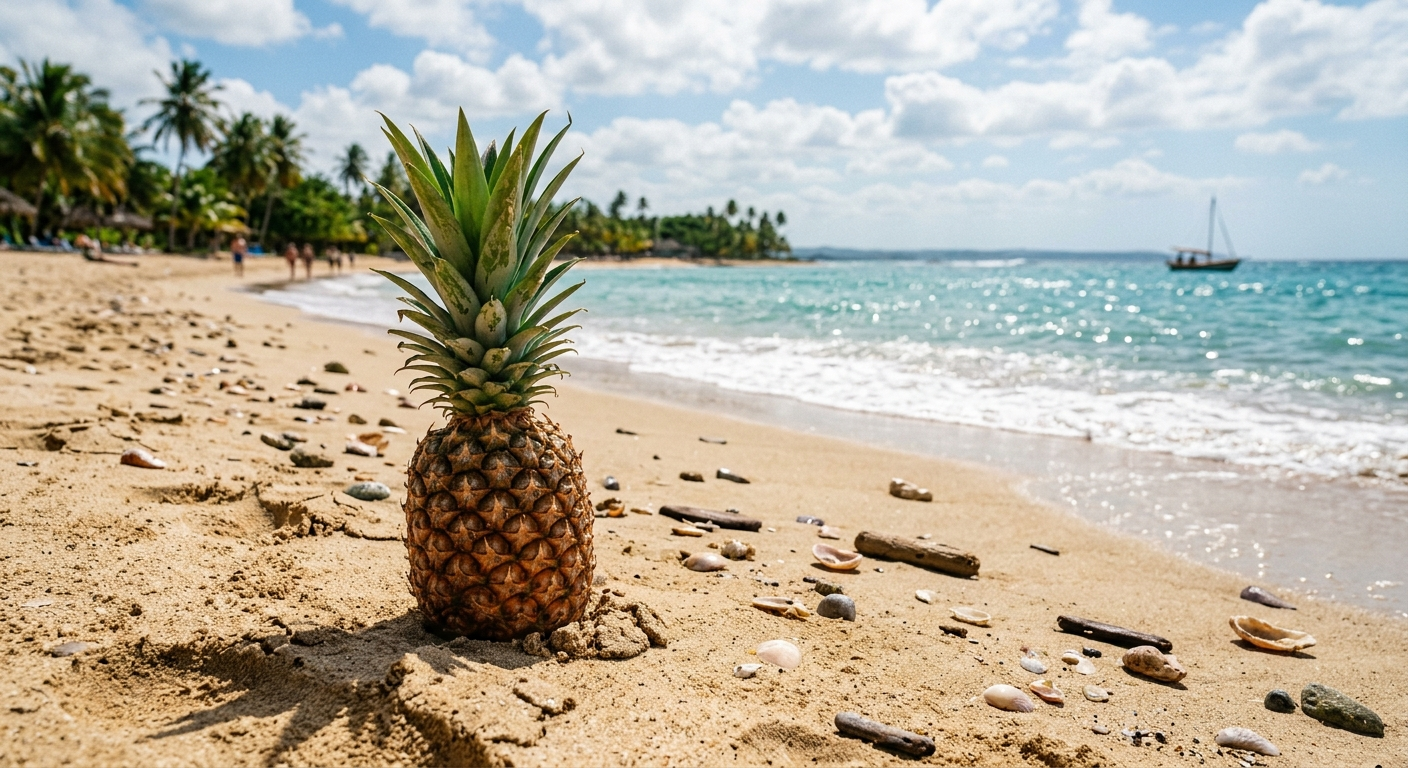

In [5]:
with Image.open("tmp/gemini-image-00000-of-00001.png") as image:
  display(image)

### Use a custom request function
Writing a custom request function to send arbitrary input to a model is relatively straightforward, as Gemini's API shares commonalities across each model type. Let's try a text-to-speech model.

In [6]:
tts_config = types.GenerateContentConfig(
      response_modalities=["AUDIO"],
      speech_config=types.SpeechConfig(
         voice_config=types.VoiceConfig(
            prebuilt_voice_config=types.PrebuiltVoiceConfig(
               voice_name='Charon',
            )
         )
      ),
   )

def generate_tts_from_string(
    model_name: str,
    batch: Sequence[str],
    model: genai.Client,
    inference_args: dict[str, any]
):
  return model.models.generate_content(model=model_name,
                                       contents=cast(Any, batch),
                                       config = tts_config)

model_handler = GeminiModelHandler(
    model_name = 'gemini-3.1-flash-tts-preview',
    request_fn=generate_tts_from_string,
    api_key=GEMINI_API_KEY,
)

class PostProcessor(beam.DoFn):
  def process(self, element: PredictionResult) -> Iterable[Any]:
    try:
      response = element.inference
      for part in response.parts:
        if part.text is not None:
          print(part.text)
        elif part.inline_data is not None:
          yield part.inline_data
    except Exception as e:
      print(f"Can't decode inference for element: {element.example}, got {e}")
      raise e


class AudioSink(FileSink):
  def open(self, fh) -> None:
    self._fh = fh

  def write(self, record):
    with wave.open(self._fh, 'wb') as f:
      f.setnchannels(1)
      f.setsampwidth(2)
      f.setframerate(16000)
      f.writeframes(record.data)

  def flush(self):
    self._fh.flush()

inputs: list[str] = [
    "Say 'Hello, World!'",
]

with beam.Pipeline() as p:
    output = (p | "Get prompts" >> beam.Create(inputs)
           | "Query Gemini" >> RunInference(model_handler)
           | "Process Output" >> beam.ParDo(PostProcessor())
           | "WriteOutput" >> WriteToFiles(
                                path='tmp/',
                                file_naming=default_file_naming("gemini-audio", ".wav"),
                                sink=AudioSink())
        )
    _ = output | "Print output" >> beam.Map(print)

FileResult(file_name='gemini-audio-00000-of-00001.wav', shard_index=0, total_shards=1, window=GlobalWindow, pane=None, destination=None)


Similar to the image output, we can load the audio output once the pipeline is complete.

In [7]:
from IPython.display import Audio
Audio(filename='tmp/gemini-audio-00000-of-00001.wav', autoplay=False)